# Red Neuronal PINN-PCA para 100 transiciones
Predicción de los coeficientes de las Componentes Principales (PCA) a partir de 16 posiciones de Hammett.
La función de pérdida (Loss) es de doble componente: MSE de los pesos PCA + MSE de la reconstrucción morfológica del espectro (Physics-Informed), garantizando una adaptación perfecta a las 100 transiciones de alta fidelidad.

## 1. Imports y Configuración global del modelo

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import time
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.spatial.distance import cosine
from scipy.integrate import trapezoid
import torch.optim as optim
import torch.nn.functional as F



torch.manual_seed(42)
np.random.seed(42)

In [13]:
from dataclasses import dataclass

@dataclass
class Config:
    # --- Parámetro clave del estudio PCA ---
    num_pcas:    int     = 10      # <--- ¡Cámbialo a 15 para hacer el otro script!

    # Arquitectura
    input_dim:   int     = 16
    hidden1:     int     = 128
    hidden2:     int     = 64
    hidden3:     int     = 32
    # El output_dim lo cogerá dinámicamente de num_pcas

    # Entrenamiento
    lr:          float   = 1e-3
    batch_size:  int     = 16
    epochs:      int     = 300
    test_size:   float   = 0.2

    # Loss Mixta (PINN)
    alpha:       float   = 1.0     # Peso del error en los parámetros PCA
    beta:        float   = 0     # Peso del error en la reconstrucción física

cfg = Config()
print(cfg)

Config(num_pcas=10, input_dim=16, hidden1=128, hidden2=64, hidden3=32, lr=0.001, batch_size=16, epochs=300, test_size=0.2, alpha=1.0, beta=0)


## 2. Carga de datos, Cálculo Delta S y PCA
Usamos los espectros completos y el heliceno base obtenidos en pasos anteriores.

In [14]:

print("📂 Cargando base de datos unificada de 100 transiciones...")

# 1. Rutas de los archivos
PATH_ECD_100 = '../Bases de datos/Dataset_ECD_100R.csv' 
PATH_BASE = '../Bases de datos/6Heliceno.csv'

# 2. Carga de DataFrames
df_ecd = pd.read_csv(PATH_ECD_100, sep=';', decimal=',').drop_duplicates(subset=['Molecula'])
df_base = pd.read_csv(PATH_BASE, sep=';', decimal=',')

# 3. Extraer X (Las 16 Posiciones de Hammett)
pos_cols = [f'Pos_{i}' for i in range(1, 17)]
X_raw = df_ecd[pos_cols].values.astype(np.float32)

# ====================================================================
# 4. GENERACIÓN DE LOS ESPECTROS CONTINUOS (S_real y S_base)
# ====================================================================
# NOTA: Tu rango es de 200 a 600 nm. Lo mantendremos así, es correcto.
wl_nm = np.linspace(200, 600, 100)
sigma_ev = 0.2
HC_EV_NM = 1240.0

print("⚙️ Calculando espectros continuos de 100 puntos (S_real) para el dataset...")
R_COLS = [f'R_{i}' for i in range(1, 101) if f'R_{i}' in df_ecd.columns]
NM_COLS = [f'nm_{i}' for i in range(1, 101) if f'nm_{i}' in df_ecd.columns]

R_matrix = df_ecd[R_COLS].values.astype(float)
NM_matrix = df_ecd[NM_COLS].values.astype(float)

S_real_list = []
for i in range(len(df_ecd)):
    r_vals = R_matrix[i]
    nm_vals = NM_matrix[i]
    spectrum_mol = np.zeros_like(wl_nm)
    
    for R, nm in zip(r_vals, nm_vals):
        if np.isnan(R) or np.isnan(nm): continue
        sigma_nm = (nm**2 / HC_EV_NM) * sigma_ev + 1e-5
        spectrum_mol += R * np.exp(-((wl_nm - nm)**2) / (2 * sigma_nm**2))
        
    S_real_list.append(spectrum_mol)

S_real = np.stack(S_real_list).astype(np.float32)

print("⚙️ Calculando espectro del heliceno base (S_base)...")
R_COLS_BASE = [f'R_{i}' for i in range(1, 101) if f'R_{i}' in df_base.columns]
NM_COLS_BASE = [f'nm_{i}' for i in range(1, 101) if f'nm_{i}' in df_base.columns]

r_base = df_base.iloc[0][R_COLS_BASE].values.astype(float)
nm_base = df_base.iloc[0][NM_COLS_BASE].values.astype(float)

S_base = np.zeros_like(wl_nm)
for R, nm in zip(r_base, nm_base):
    if np.isnan(R) or np.isnan(nm): continue
    sigma_nm = (nm**2 / HC_EV_NM) * sigma_ev + 1e-5
    S_base += R * np.exp(-((wl_nm - nm)**2) / (2 * sigma_nm**2))

S_base = S_base.astype(np.float32)

# ====================================================================
# PASO 1: CÁLCULO DEL RESIDUAL (Delta S en unidades originales)
# ====================================================================
Delta_S = S_real - S_base

print(f'\n✅ Datos cargados y procesados con éxito.')
print(f'   - Moléculas procesadas: {X_raw.shape[0]}')
print(f'   - X_raw (Hammett 16 pos):  {X_raw.shape}')
print(f'   - S_real (100 puntos):     {S_real.shape}')
print(f'   - Delta_S (100 puntos):    {Delta_S.shape}')

📂 Cargando base de datos unificada de 100 transiciones...
⚙️ Calculando espectros continuos de 100 puntos (S_real) para el dataset...
⚙️ Calculando espectro del heliceno base (S_base)...

✅ Datos cargados y procesados con éxito.
   - Moléculas procesadas: 12407
   - X_raw (Hammett 16 pos):  (12407, 16)
   - S_real (100 puntos):     (12407, 100)
   - Delta_S (100 puntos):    (12407, 100)


## 3. Normalización, Split de Datos y PCA 


In [15]:
# ==============================================================================
# PASO 0: NORMALIZACIÓN 1 Y GENERACIÓN DEL GROUND TRUTH (S_true)
# ==============================================================================

def norm1_forward(S, max_abs_val):
    """Escala dividiendo por el valor absoluto máximo para no deformar la curva"""
    return S / max_abs_val

def norm1_inverse(S_norm, max_abs_val):
    """Invierte la normalización multiplicando por el valor absoluto máximo"""
    return S_norm * max_abs_val
def norm_wl_forward(wl, wl_min, wl_max):
    """Escala las longitudes de onda (eje X) al rango [-1, 1]"""
    return 2.0 * (wl - wl_min) / (wl_max - wl_min) - 1.0

def norm_wl_inverse(wl_norm, wl_min, wl_max):
    """Devuelve las longitudes de onda a nanómetros reales"""
    return (wl_norm + 1.0) / 2.0 * (wl_max - wl_min) + wl_min

# ------------------------------------------------------------------------------
# 2. Extracción de máximos y mínimos GLOBALES de la base de datos
R_min_global = float(np.min(S_real))
R_max_global = float(np.max(S_real))
# Extraemos el valor absoluto máximo de toda la base de datos
R_max_abs_global = float(np.max(np.abs(S_real)))
wl_min = float(np.min(wl_nm))
wl_max = float(np.max(wl_nm))

# ------------------------------------------------------------------------------
# 3. Generación del Ground Truth (S_true_norm1) y normalización del eje X
S_true_norm1 = norm1_forward(S_real, R_max_abs_global)
wl_norm = norm_wl_forward(wl_nm, wl_min, wl_max)

print(f"✅ Paso 0 completado. Parámetros de normalización guardados:")
print(f"   Rango Intensidad original: [{R_min_global:.4f}, {R_max_global:.4f}] -> S_true_norm1: [{np.min(S_true_norm1):.4f}, {np.max(S_true_norm1):.4f}]")
print(f"   Rango Longitud de onda:    [{wl_min:.1f}, {wl_max:.1f}] nm -> wl_norm: [{np.min(wl_norm):.1f}, {np.max(wl_norm):.1f}]")

✅ Paso 0 completado. Parámetros de normalización guardados:
   Rango Intensidad original: [-1413.0093, 1407.4301] -> S_true_norm1: [-1.0000, 0.9961]
   Rango Longitud de onda:    [200.0, 600.0] nm -> wl_norm: [-1.0, 1.0]


In [16]:
# ==============================================================================
# PASO 2: DIVISIÓN TRAIN/TEST Y NORMALIZACIÓN 2 (Solo en Train)
# ==============================================================================

print("⚙️ Dividiendo datos y aplicando Normalización 2...")

# 1. División Train / Test 
# Usamos cfg.test_size si tienes un objeto 'cfg' definido, si no, pon 0.2 directamente.
idx = np.arange(len(X_raw))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42) # Cambia 0.2 por cfg.test_size si lo prefieres

# 2. Normalizar Entradas X (Constantes de Hammett)
# StandardScaler se ajusta SOLO al train para evitar fuga de datos
scaler_X = StandardScaler()
X_tr_norm = scaler_X.fit_transform(X_raw[idx_tr])
X_te_norm = scaler_X.transform(X_raw[idx_te])

# 3. Funciones matemáticas para la Normalización 2
def norm2_forward(S_res, max_abs_res):
    """Escala a [-1, 1] dividiendo por el máximo absoluto"""
    return S_res / max_abs_res

def norm2_inverse(S_res_norm, max_abs_res):
    """Desescala el residuo a unidades originales"""
    return S_res_norm * max_abs_res

# 4. Normalización 2 de Intensidades Residuales (Delta_S)
# ¡CRÍTICO!: Buscamos el máximo absoluto SÓLO en el conjunto de entrenamiento
max_abs_res_train = float(np.max(np.abs(Delta_S[idx_tr])))

# Aplicamos la normalización a Train y Test usando siempre el máximo del Train
Delta_S_tr_norm2 = norm2_forward(Delta_S[idx_tr], max_abs_res_train)
Delta_S_te_norm2 = norm2_forward(Delta_S[idx_te], max_abs_res_train)

print(f"✅ Paso 2 completado.")
print(f"   - Muestras Train: {len(idx_tr)} | Muestras Test: {len(idx_te)}")
print(f"   - Máximo absoluto del residuo en Train: {max_abs_res_train:.4f}")
print(f"   - Rango Delta_S Train (Norm 2): [{np.min(Delta_S_tr_norm2):.2f}, {np.max(Delta_S_tr_norm2):.2f}]")
print(f"   - Rango Delta_S Test (Norm 2):  [{np.min(Delta_S_te_norm2):.2f}, {np.max(Delta_S_te_norm2):.2f}]")

⚙️ Dividiendo datos y aplicando Normalización 2...
✅ Paso 2 completado.
   - Muestras Train: 9925 | Muestras Test: 2482
   - Máximo absoluto del residuo en Train: 1895.3535
   - Rango Delta_S Train (Norm 2): [-1.00, 0.73]
   - Rango Delta_S Test (Norm 2):  [-0.70, 0.52]


In [17]:
from sklearn.decomposition import PCA
import torch
from torch.utils.data import DataLoader, TensorDataset

# ==============================================================================
# PASO 3: PCA (SÓLO EN TRAIN) Y ESTANDARIZACIÓN A [-1, 1]
# ==============================================================================

print("⚙️ Ajustando PCA sobre los residuos de Train...")

# 1. Ajuste del PCA solo con los datos de Train
# Usa cfg.num_pcas si lo tienes, si no, pon 10 directamente
num_pcas = 10 
pca_final = PCA(n_components=num_pcas, random_state=42)

# Ajustamos (fit) y transformamos el Train. Al Test SOLO lo transformamos.
pesos_tr_raw = pca_final.fit_transform(Delta_S_tr_norm2)
pesos_te_raw = pca_final.transform(Delta_S_te_norm2)

# Guardamos los componentes (las 10 formas de onda). Son universales para desescalar.
componentes_pca = pca_final.components_  

print(f"✅ Varianza explicada por {num_pcas} PCAs en Train: {np.sum(pca_final.explained_variance_ratio_) * 100:.2f}%")

# 2. Estandarización de los coeficientes PCA a [-1, 1]
def pca_scores_forward(scores, pca_mins, pca_maxs):
    """Escala los coeficientes PCA al rango [-1, 1]"""
    return 2.0 * (scores - pca_mins) / (pca_maxs - pca_mins) - 1.0

def pca_scores_inverse(scores_norm, pca_mins, pca_maxs):
    """Desescala devolviendo los coeficientes PCA reales (para la Loss luego)"""
    return (scores_norm + 1.0) / 2.0 * (pca_maxs - pca_mins) + pca_mins

# Buscamos los máximos y mínimos de cada componente PCA SÓLO en el Train
pca_mins = np.min(pesos_tr_raw, axis=0)
pca_maxs = np.max(pesos_tr_raw, axis=0)

# Aplicamos la normalización
pesos_tr_norm = pca_scores_forward(pesos_tr_raw, pca_mins, pca_maxs)
pesos_te_norm = pca_scores_forward(pesos_te_raw, pca_mins, pca_maxs)


# ==============================================================================
# CREACIÓN DE TENSORES Y DATALOADERS PARA PYTORCH
# ==============================================================================
def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

# Entradas (Hammett)
X_tr,  X_te  = to_t(X_tr_norm),       to_t(X_te_norm)
# Salidas directas de la red (PCA scores)
Yw_tr, Yw_te = to_t(pesos_tr_norm),   to_t(pesos_te_norm)
# Target Físico final (S_true normalizado)
Ys_tr, Ys_te = to_t(S_true_norm1[idx_tr]), to_t(S_true_norm1[idx_te])

# Usa cfg.batch_size si lo tienes, si no, pon un número como 32 o 64
batch_size = 32 
train_loader = DataLoader(TensorDataset(X_tr, Yw_tr, Ys_tr), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_te, Yw_te, Ys_te), batch_size=batch_size, shuffle=False)

print(f'\n📊 Resumen de tensores listos para la Red Neuronal:')
print(f'   - Rango PCA scores Train: [{torch.min(Yw_tr):.2f}, {torch.max(Yw_tr):.2f}]')
print(f'   - Rango PCA scores Test:  [{torch.min(Yw_te):.2f}, {torch.max(Yw_te):.2f}]')
print(f'   - Rango S_true_norm1:     [{torch.min(Ys_tr):.2f}, {torch.max(Ys_tr):.2f}]')

⚙️ Ajustando PCA sobre los residuos de Train...
✅ Varianza explicada por 10 PCAs en Train: 97.93%

📊 Resumen de tensores listos para la Red Neuronal:
   - Rango PCA scores Train: [-1.00, 1.00]
   - Rango PCA scores Test:  [-1.10, 1.54]
   - Rango S_true_norm1:     [-1.00, 1.00]


# Visualización de PCA

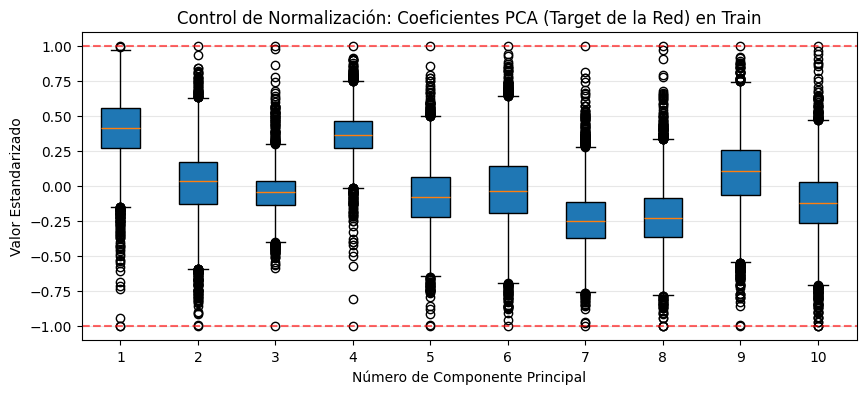

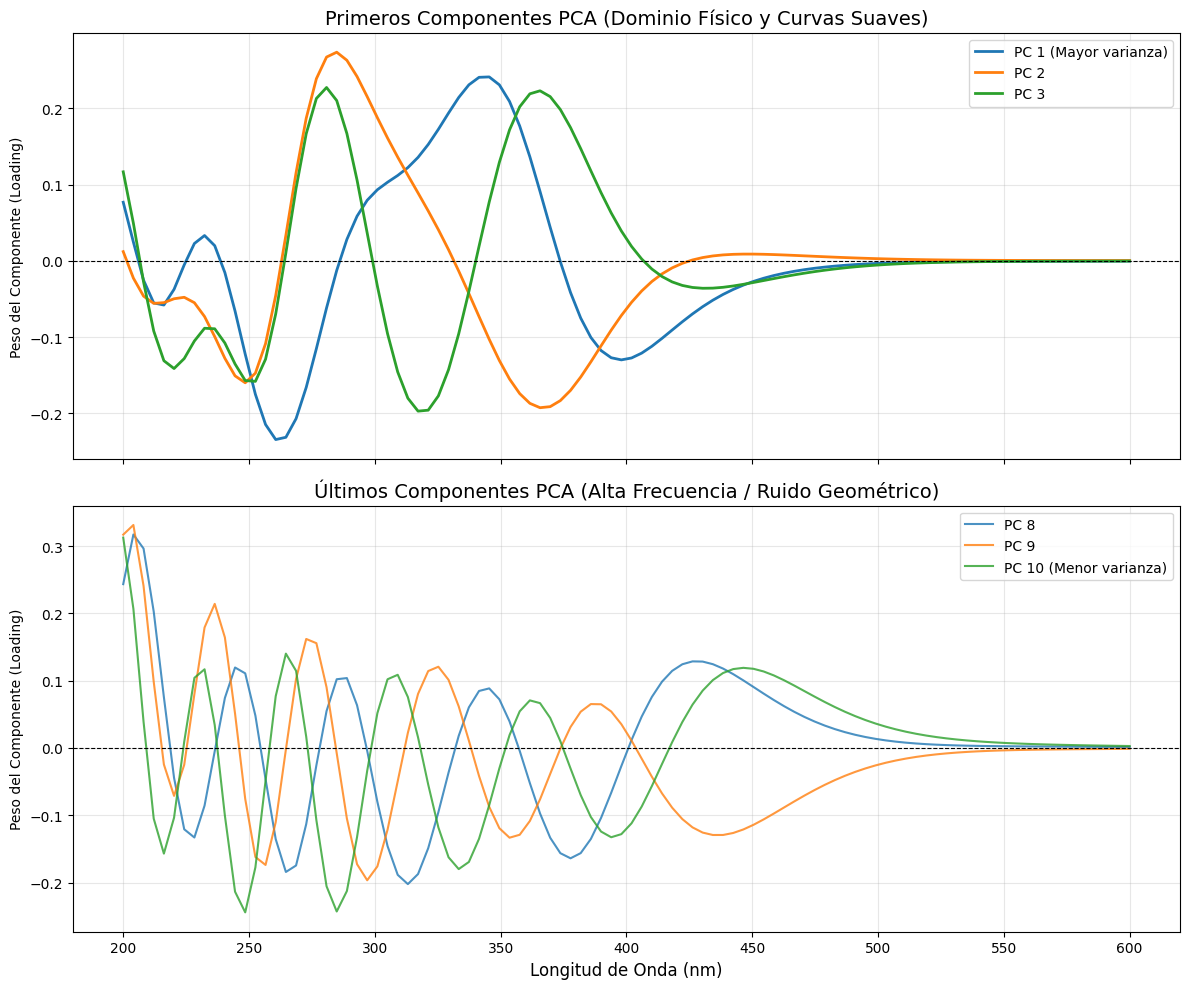

In [18]:
import matplotlib.pyplot as plt

# ==============================================================================
# 1. VISUALIZACIÓN DE CONTROL: Distribución de Scores (Para nosotros)
# ==============================================================================
plt.figure(figsize=(10, 4))
plt.boxplot(pesos_tr_norm, patch_artist=True)
plt.title("Control de Normalización: Coeficientes PCA (Target de la Red) en Train")
plt.xlabel("Número de Componente Principal")
plt.ylabel("Valor Estandarizado")
plt.axhline(1, color='red', linestyle='--', alpha=0.6)
plt.axhline(-1, color='red', linestyle='--', alpha=0.6)
plt.grid(axis='y', alpha=0.3)
plt.show()

# ==============================================================================
# 2. VISUALIZACIÓN CIENTÍFICA: "Loadings" del PCA como Espectros (Para el TFG)
# ==============================================================================
# componentes_pca tiene forma (10, 100), cada fila es una "forma de onda" fundamental
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Gráfica Arriba: Primeros componentes (La señal física "real")
axes[0].set_title("Primeros Componentes PCA (Dominio Físico y Curvas Suaves)", fontsize=14)
axes[0].plot(wl_nm, componentes_pca[0], label='PC 1 (Mayor varianza)', linewidth=2)
axes[0].plot(wl_nm, componentes_pca[1], label='PC 2', linewidth=2)
axes[0].plot(wl_nm, componentes_pca[2], label='PC 3', linewidth=2)
axes[0].set_ylabel("Peso del Componente (Loading)")
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfica Abajo: Últimos componentes (El "ruido" matemático)
axes[1].set_title("Últimos Componentes PCA (Alta Frecuencia / Ruido Geométrico)", fontsize=14)
axes[1].plot(wl_nm, componentes_pca[7], label='PC 8', linewidth=1.5, alpha=0.8)
axes[1].plot(wl_nm, componentes_pca[8], label='PC 9', linewidth=1.5, alpha=0.8)
axes[1].plot(wl_nm, componentes_pca[9], label='PC 10 (Menor varianza)', linewidth=1.5, alpha=0.8)
axes[1].set_xlabel("Longitud de Onda (nm)", fontsize=12)
axes[1].set_ylabel("Peso del Componente (Loading)")
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Arquitectura de la red neuronal
Aprovechamos el truco de la simetría molecular (C2 del heliceno) invirtiendo el tensor de entrada y promediando.

In [19]:
import torch
import torch.nn as nn

# ==============================================================================
# DEFINICIÓN DE LA ARQUITECTURA DEL MODELO
# ==============================================================================

class HelicenoPCANet(nn.Module):
    """
    Red neuronal profunda para predecir los pesos PCA del espectro.
    Incluye simetría forzada en el forward pass y Batch Normalization.
    """
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.input_dim, cfg.hidden1),
            nn.BatchNorm1d(cfg.hidden1),  
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(cfg.hidden1, cfg.hidden2),
            nn.BatchNorm1d(cfg.hidden2),  
            nn.ReLU(),
            nn.Dropout(0.1), # Opcional: añadir dropout aquí también si hay overfitting
            
            nn.Linear(cfg.hidden2, cfg.hidden3), 
            nn.BatchNorm1d(cfg.hidden3),  
            nn.ReLU(),
            
            nn.Linear(cfg.hidden3, cfg.num_pcas),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Promedia la salida de X con la salida de X invertido para forzar simetría
        x_flip = torch.flip(x, dims=[1])
        return 0.5 * (self.net(x) + self.net(x_flip))

# Instanciamos el modelo usando tu objeto de configuración (cfg)
model = HelicenoPCANet(cfg)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\n✅ Modelo instanciado correctamente.')
print(f'   Parámetros entrenables: {n_params}')

HelicenoPCANet(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=10, bias=True)
  )
)

✅ Modelo instanciado correctamente.
   Parámetros entrenables: 13290


## Definición de métricas que usaremos

In [20]:

def calcular_metricas_globales(Y_true, Y_pred, wl_nm):
    """
    Calcula y devuelve las métricas de evaluación espectral.
    Y_true, Y_pred: Arrays de NumPy con los espectros reales y predichos (N_muestras, 100)
    wl_nm: Eje X de longitudes de onda para calcular la integral (IAD).
    """
    mae = mean_absolute_error(Y_true.flatten(), Y_pred.flatten())
    mse = mean_squared_error(Y_true.flatten(), Y_pred.flatten())
    rmse = np.sqrt(mse)
    r2 = r2_score(Y_true.flatten(), Y_pred.flatten())
    
    # Similitud del Coseno (promedio por molécula)
    cosenos = []
    for i in range(len(Y_true)):
        if np.all(Y_true[i] == 0) or np.all(Y_pred[i] == 0):
            cosenos.append(0.0)
        else:
            cosenos.append(1.0 - cosine(Y_true[i], Y_pred[i]))
    coseno_medio = np.mean(cosenos)
    
    # Integral de Área de Discrepancia (IAD)
    iad_array = trapezoid(np.abs(Y_true - Y_pred), x=wl_nm, axis=1)
    iad_medio = np.mean(iad_array)
    
    return mae, mse, rmse, r2, coseno_medio, iad_medio

print("Herramientas de cálculo de métricas definidas correctamente.")

Herramientas de cálculo de métricas definidas correctamente.


## 6. Construcción del espectro y función de pérdida

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# ==============================================================================
# PASO 4 (PARTE A): DEFINICIÓN DE LA LOSS Y CONFIGURACIÓN
# ==============================================================================

class PCASpectrumLoss(nn.Module):
    def __init__(self, pca_components, pca_mins, pca_maxs, max_abs_res, S_base, R_max_abs):
        super(PCASpectrumLoss, self).__init__()
        self.pca_components = torch.tensor(pca_components, dtype=torch.float32)
        self.pca_mins = torch.tensor(pca_mins, dtype=torch.float32)
        self.pca_maxs = torch.tensor(pca_maxs, dtype=torch.float32)
        self.max_abs_res = torch.tensor(max_abs_res, dtype=torch.float32)
        self.S_base = torch.tensor(S_base, dtype=torch.float32)
        self.R_max_abs = torch.tensor(R_max_abs, dtype=torch.float32)

    def forward(self, y_pred, y_true, S_true_target):
        # 1. MSE de los coeficientes PCA (La única activa por ahora)
        loss_alpha = F.mse_loss(y_pred, y_true)
        
        # ====================================================================
        # 2. MSE del espectro reconstruido (Comentado según instrucciones)
        # ====================================================================
        # scores_pred = (y_pred + 1.0) / 2.0 * (self.pca_maxs - self.pca_mins) + self.pca_mins
        # S_res_norm2_pred = torch.matmul(scores_pred, self.pca_components)
        # S_res_pred = S_res_norm2_pred * self.max_abs_res
        # S_pred_orig = S_res_pred + self.S_base
        # S_pred_norm1 = S_pred_orig / self.R_max_abs
        # loss_beta = F.mse_loss(S_pred_norm1, S_true_target)
        # return loss_alpha + loss_beta
        
        return loss_alpha

# Instanciamos la Loss
criterion = PCASpectrumLoss(
    pca_components=componentes_pca,
    pca_mins=pca_mins,
    pca_maxs=pca_maxs,
    max_abs_res=max_abs_res_train,
    S_base=S_base,              
    R_max_abs=R_max_abs_global
)

# Configuramos el optimizador
optimizer = optim.Adam(model.parameters(), lr=cfg.lr if hasattr(cfg, 'lr') else 1e-3)
epochs = cfg.epochs if hasattr(cfg, 'epochs') else 200 

print(f"✅ Loss, Optimizador y Épocas ({epochs}) configurados. Listos para entrenar.")

✅ Loss, Optimizador y Épocas (300) configurados. Listos para entrenar.


## 7. Entrenamiento

In [22]:
import os
import torch

# 1. Optimizador y Scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=1e-5)

# 2. Historial de métricas
history = {'total': [], 'params': [], 'spectra': [],
           'val_total': [], 'val_params': [], 'val_spectra': []}

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15
)

# 3. Configuración Early Stopping
paciencia_max = 60 
paciencia_actual = 0
mejor_val_loss = float('inf')

print(f'Entrenando máximo {cfg.epochs} épocas con Early Stopping...')

# 4. Bucle de Entrenamiento
for epoch in range(1, cfg.epochs + 1):

    # ── Train
    model.train()
    ep_total, ep_params, ep_spectra = 0.0, 0.0, 0.0
    for bX, bYw, bYs in train_loader:
        optimizer.zero_grad()
        pred = model(bX)
        
        # Usamos nuestro nuevo criterion (Paso 4)
        # lp = loss_alpha (PCA), ls = loss_beta (Espectro)
        loss = criterion(pred, bYw, bYs) 
        
        loss.backward()
        optimizer.step()
        
        # Como beta está comentado en el criterion, ls es 0.0
        ep_total += loss.item()
        ep_params += loss.item() # lp
        ep_spectra += 0.0       # ls

    n_tr = len(train_loader)
    history['total'].append(ep_total / n_tr)
    history['params'].append(ep_params / n_tr)
    history['spectra'].append(ep_spectra / n_tr)

    # ── Validation
    model.eval()
    vt, vp, vs = 0.0, 0.0, 0.0
    with torch.no_grad():
        for bX, bYw, bYs in test_loader:
            pred = model(bX)
            loss = criterion(pred, bYw, bYs)
            
            vt += loss.item()
            vp += loss.item() # lp
            vs += 0.0         # ls
            
    n_te = len(test_loader)
    current_val_loss = vt / n_te
    history['val_total'].append(current_val_loss)
    history['val_params'].append(vp / n_te)
    history['val_spectra'].append(vs / n_te)

    scheduler.step(current_val_loss)
    
    # ── Early Stopping y Guardado del Modelo
    if current_val_loss < mejor_val_loss:
        mejor_val_loss = current_val_loss
        paciencia_actual = 0
        torch.save(model.state_dict(), f'mejor_modelo_pinn_pca_{cfg.num_pcas}.pt')
    else:
        paciencia_actual += 1

    if epoch % 25 == 0:
        print(f'Época {epoch:4d} | '
              f'Train total={history["total"][-1]:.4f} '
              f'(params={history["params"][-1]:.4f}, spec={history["spectra"][-1]:.4f}) | '
              f'Val total={history["val_total"][-1]:.4f} | '
              f'Paciencia: {paciencia_actual}/{paciencia_max}')

    if paciencia_actual >= paciencia_max:
        print(f'\n[!] Early Stopping activado en la época {epoch}.')
        break

print('\n¡Entrenamiento completado!')
model.load_state_dict(torch.load(f'mejor_modelo_pinn_pca_{cfg.num_pcas}.pt'))
print(f"-> Se han cargado los pesos óptimos. Mejor Val Loss (Total): {mejor_val_loss:.4f}")

Entrenando máximo 300 épocas con Early Stopping...
Época   25 | Train total=0.0352 (params=0.0352, spec=0.0000) | Val total=0.0334 | Paciencia: 0/60
Época   50 | Train total=0.0343 (params=0.0343, spec=0.0000) | Val total=0.0332 | Paciencia: 7/60
Época   75 | Train total=0.0332 (params=0.0332, spec=0.0000) | Val total=0.0326 | Paciencia: 15/60
Época  100 | Train total=0.0330 (params=0.0330, spec=0.0000) | Val total=0.0325 | Paciencia: 12/60
Época  125 | Train total=0.0325 (params=0.0325, spec=0.0000) | Val total=0.0333 | Paciencia: 37/60
Época  150 | Train total=0.0325 (params=0.0325, spec=0.0000) | Val total=0.0328 | Paciencia: 9/60
Época  175 | Train total=0.0323 (params=0.0323, spec=0.0000) | Val total=0.0324 | Paciencia: 17/60
Época  200 | Train total=0.0323 (params=0.0323, spec=0.0000) | Val total=0.0324 | Paciencia: 42/60

[!] Early Stopping activado en la época 218.

¡Entrenamiento completado!
-> Se han cargado los pesos óptimos. Mejor Val Loss (Total): 0.0317


## 8. Curvas de pérdida
Se combinan las pérdidas de los valores de los parámetros y los del espectro reconstruido.

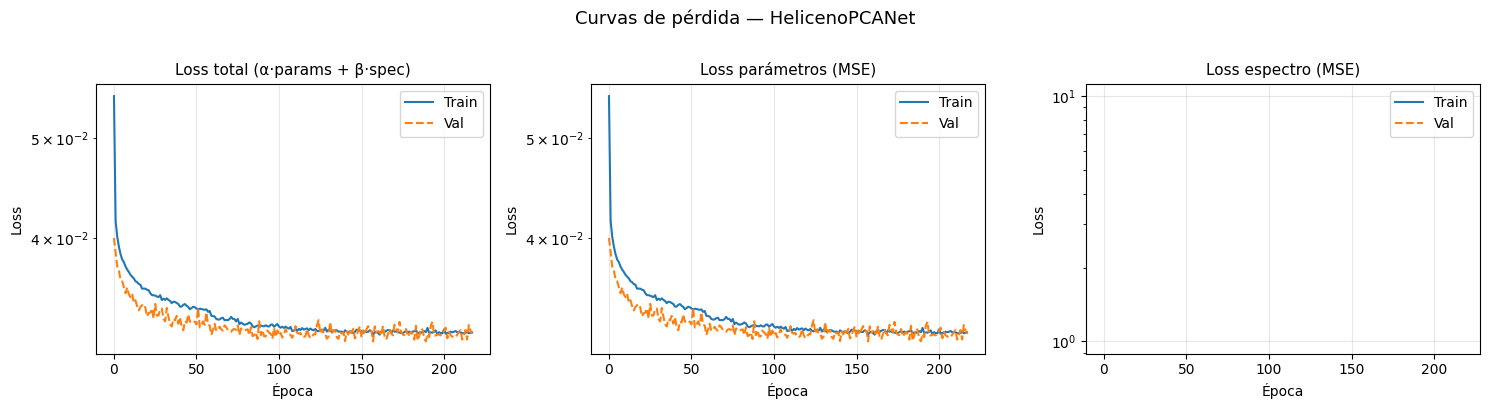

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('total', 'Loss total (α·params + β·spec)'),
         ('params', 'Loss parámetros (MSE)'),
         ('spectra', 'Loss espectro (MSE)')]

for ax, (key, title) in zip(axes, pairs):
    ax.plot(history[key],     label='Train', linewidth=1.5)
    ax.plot(history[f'val_{key}'], label='Val',   linewidth=1.5, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de pérdida — HelicenoPCANet', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Métricas sobre el conjunto test
Se calculan en **escala real** y **escala normalizada** para poder comparar correctamente.
Se calculan MAE, MSE, RMSE, R2, nMAE, nMSE, MAPE(%) y MaxErr.

In [25]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Definimos la función de reconstrucción (usando los tensores que ya calculamos)
def build_spectrum_pca(weights):
    """Reconstruye el espectro original a partir de los pesos PCA de la red."""
    # Convertimos a tensores si no lo son
    w = weights.clone().detach() if isinstance(weights, torch.Tensor) else torch.tensor(weights)
    
    # a) Desestandarizar pesos: [-1, 1] -> PCA raw
    # Usamos las constantes pca_mins/maxs del Paso 3
    pca_mins_t = torch.tensor(pca_mins, dtype=torch.float32)
    pca_maxs_t = torch.tensor(pca_maxs, dtype=torch.float32)
    scores = (w + 1.0) / 2.0 * (pca_maxs_t - pca_mins_t) + pca_mins_t
    
    # b) Combinación lineal -> Residuo Norm2
    components_t = torch.tensor(componentes_pca, dtype=torch.float32)
    res_norm2 = torch.matmul(scores, components_t)
    
    # c) Invertir Normalización 2 (max_abs_res_train)
    res_orig = res_norm2 * torch.tensor(max_abs_res_train, dtype=torch.float32)
    
    # d) Sumar heliceno base
    return res_orig + torch.tensor(S_base, dtype=torch.float32)

# 2. Definimos las métricas
def calcular_metricas_globales(y_true, y_pred, wl):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    # Coseno: Similarity entre vectores espectrales
    # Evitamos división por cero con un epsilon pequeño
    norm_true = np.linalg.norm(y_true, axis=1)
    norm_pred = np.linalg.norm(y_pred, axis=1)
    coseno = np.mean(np.sum(y_true * y_pred, axis=1) / ((norm_true * norm_pred) + 1e-10))
    
    # IAD: Integrated Absolute Difference (error relativo en porcentaje)
    iad = np.sum(np.abs(y_true - y_pred), axis=1) / (np.sum(np.abs(y_true), axis=1) + 1e-10)
    iad_medio = np.mean(iad) * 100
    
    return mae, mse, rmse, r2, coseno, iad_medio

# ==============================================================================
# INFERENCIA Y EVALUACIÓN FINAL
# ==============================================================================
print("📊 INFERENCIA Y EVALUACIÓN FINAL EN EL CONJUNTO DE TEST...")

model.eval()
with torch.no_grad():
    # Predecimos y reconstruimos
    pred_weights_norm = model(X_te)
    pred_spectra_tensor = build_spectrum_pca(pred_weights_norm)

# Convertimos a NumPy (Ground truth es S_real[idx_te])
Y_pred = pred_spectra_tensor.numpy()
Y_true = S_real[idx_te] 

# Llamamos a nuestra función de métricas
mae, mse, rmse, r2, coseno_medio, iad_medio = calcular_metricas_globales(Y_true, Y_pred, wl_nm)

# Imprimir resultados
print("=" * 50)
print(f" RESULTADOS FINALES PINN-PCA ({cfg.num_pcas} Componentes)")
print("=" * 50)
print(f"  MAE:     {mae:.4f}")
print(f"  MSE:     {mse:.4f}")
print(f"  RMSE:    {rmse:.4f}")
print(f"  R²:      {r2:.4f}")
print(f"  Coseno:  {coseno_medio:.4f}")
print(f"  IAD:     {iad_medio:.4f} %")
print("=" * 50)

# Guardado
with open(f"Resultados_Test_PCA_{cfg.num_pcas}.txt", "w") as f:
    f.write(f"N_PCA: {cfg.num_pcas}\nMAE: {mae}\nMSE: {mse}\nRMSE: {rmse}\nR2: {r2}\nCoseno: {coseno_medio}\nIAD: {iad_medio}\n")
print(f"✅ Resultados guardados en 'Resultados_Test_PCA_{cfg.num_pcas}.txt'")

📊 INFERENCIA Y EVALUACIÓN FINAL EN EL CONJUNTO DE TEST...
 RESULTADOS FINALES PINN-PCA (10 Componentes)
  MAE:     105.5902
  MSE:     29306.1191
  RMSE:    171.1903
  R²:      -0.9624
  Coseno:  0.6762
  IAD:     108.7840 %
✅ Resultados guardados en 'Resultados_Test_PCA_10.txt'


# Tests

In [26]:
# Evaluar sobre el Train (si el modelo es capaz de aprender, aquí debería dar un R2 > 0.8)
model.eval()
with torch.no_grad():
    pred_weights_train = model(X_tr) # X_tr es el de entrenamiento
    pred_spectra_train = build_spectrum_pca(pred_weights_norm) # (Cuidado: esto reconstruye a partir del batch test, usa X_tr)
    # Mejor crea esta mini-función de inferencia:
    
    # Inferencia rápida Train
    p_train = build_spectrum_pca(model(X_tr))
    y_true_train = S_real[idx_tr] # Ground truth train
    
    mae_tr, mse_tr, rmse_tr, r2_tr, cos_tr, iad_tr = calcular_metricas_globales(y_true_train, p_train.numpy(), wl_nm)
    print(f"RESULTADOS TRAIN: R2 = {r2_tr:.4f} | Cos = {cos_tr:.4f}")

RESULTADOS TRAIN: R2 = -0.8520 | Cos = 0.6772


In [27]:
# Evaluar solo la capacidad de predecir los coeficientes PCA
model.eval()
with torch.no_grad():
    y_pred_pca = model(X_te) # Predicción (Batch x 10)
    y_true_pca = Yw_te       # Target (Batch x 10)

# Calculamos R2 componente a componente para ver si alguno falla
from sklearn.metrics import r2_score
r2_components = r2_score(y_true_pca.numpy(), y_pred_pca.numpy(), multioutput='raw_values')

print(f"R2 promedio en PCA: {np.mean(r2_components):.4f}")
print("R2 por componente PCA:")
print(r2_components)

R2 promedio en PCA: 0.2938
R2 por componente PCA:
[0.52535033 0.46325827 0.31668353 0.19158816 0.29438716 0.25863254
 0.43922997 0.1477626  0.18458426 0.11650383]


## 11. Visualización: 4 ejemplos aleatorios del test

In [ ]:
# ====================================================================
# --- VISUALIZAR 4 MUESTRAS DEL CONJUNTO DE TEST (MODELO PCA) ---
# ====================================================================
np.random.seed(42) 
# Elegimos 4 índices al azar del conjunto de test
indices_muestra = np.random.choice(len(Y_pred), size=4, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, i in zip(axes, indices_muestra):
    # Espectros en escala real
    ax.plot(wl_nm, Y_true[i],  label='Real (100 transiciones)', linewidth=2, color='steelblue')
    ax.plot(wl_nm, Y_pred[i],  label='Predicho (PINN-PCA)', linewidth=2, color='tomato', linestyle='--')

    # Calcular métricas locales para el título
    mae_i = mean_absolute_error(Y_true[i], Y_pred[i])
    r2_i  = r2_score(Y_true[i], Y_pred[i])
    
    ax.set_title(f'Muestra Test #{i} | MAE: {mae_i:.2f} | R²: {r2_i:.3f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Longitud de onda (nm)')
    ax.set_ylabel('Intensidad (Escala real)')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='dotted')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Modelo PINN-PCA ({cfg.num_pcas} PCAs): Espectros Reales vs Predichos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Guardar modelo y parámetros de normalización

In [ ]:
# ====================================================================
# --- GUARDADO COMPLETO DEL MODELO PARA INFERENCIA FUTURA ---
# ====================================================================
nombre_archivo = f'modelo_pinn_pca_{cfg.num_pcas}_completo.pt'

torch.save({
    'model_state':    model.state_dict(),
    'config':         cfg,
    'I_SCALE':        I_SCALE,
    'S_base':         S_base,             # Vital para sumar la base
    'pca_components': componentes_pca,    # Vital para multiplicar por los pesos
    'wl_nm':          wl_nm,
    'scaler_X_mean':  scaler_X.mean_,     # Para normalizar las entradas nuevas
    'scaler_X_scale': scaler_X.scale_
}, nombre_archivo)

print(f'✅ Modelo PCA y todos sus hiperparámetros guardados en {nombre_archivo}')